In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression

In [2]:
data = pd.read_csv("../HW3/data/output/final_star.csv")

/tmp/ipykernel_211580/3584565233.py:1: DtypeWarning: Columns (100,101,102,103,104,105,106,107,108,111) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../HW3/data/output/final_star.csv")


In [3]:
print(list(data.columns))

['contractid', 'planid', 'fips', 'year', 'n_nonmiss', 'avg_enrollment', 'sd_enrollment', 'min_enrollment', 'max_enrollment', 'first_enrollment', 'last_enrollment', 'state', 'county', 'org_type', 'plan_type', 'partd', 'snp', 'eghp', 'org_name', 'org_marketing_name', 'plan_name', 'parent_org', 'contract_date', 'state_long', 'county_long', 'year_pen', 'n_elig', 'n_enrol', 'avg_eligibles', 'sd_eligibles', 'min_eligibles', 'max_eligibles', 'first_eligibles', 'last_eligibles', 'avg_enrolled', 'sd_enrolled', 'min_enrolled', 'max_enrolled', 'first_enrolled', 'last_enrolled', 'ssa', 'state_name', 'state_land', 'premium', 'premium_partc', 'premium_partd_basic', 'premium_partd_supp', 'premium_partd_total', 'partd_deductible', 'year_land', 'riskscore_partc', 'payment_partc', 'rebate_partc', 'year_reb', 'payment_partd', 'directsubsidy_partd', 'reinsurance_partd', 'costsharing_partd', 'riskscore_partd', 'avg_ffscost', 'parta_enroll', 'partb_enroll', 'metric_01', 'metric_02', 'metric_03', 'metric_04'

In [4]:
# Question 1: 

d1 = data.copy()

# choose and clean variables
d1["star_rating"] = pd.to_numeric(d1["partcd_score"], errors="coerce")
d1["enrollment"] = pd.to_numeric(d1["avg_enrollment"], errors="coerce")
d1["market_share"] = np.where(
    pd.to_numeric(d1["avg_enrolled"], errors="coerce") > 0,
    d1["enrollment"] / pd.to_numeric(d1["avg_enrolled"], errors="coerce"),
    np.nan
)

# create table
summary = (
    d1.loc[d1["year"].between(2010, 2015)]
      .groupby("year")
      .agg(
          mean_star_rating=("star_rating", "mean"),
          mean_enrollments=("enrollment", "mean"),
          mean_market_share=("market_share", "mean"),
          n_plans=("planid", "count"),
      )
      .reset_index()
      .sort_values("year")
)

summary

,year,mean_star_rating,mean_enrollments,mean_market_share,n_plans
0,2010,2.969662,256.353663,0.064564,108222
1,2011,3.165988,343.358734,0.085547,68003
2,2012,3.352218,377.336484,0.085568,67254
3,2013,3.559948,395.516174,0.081451,68117
4,2014,3.824169,436.637121,0.079989,62344
5,2015,3.977247,469.679258,0.078689,65507


In [5]:
# Question 2

no_star_summary = (
    data.loc[data["year"].between(2010, 2015)]
        .assign(
            star_rating=lambda d: pd.to_numeric(d["partcd_score"], errors="coerce"),
            enrollment=lambda d: pd.to_numeric(d["avg_enrollment"], errors="coerce"),
            market_share=lambda d: np.where(
                pd.to_numeric(d["avg_enrolled"], errors="coerce") > 0,
                pd.to_numeric(d["avg_enrollment"], errors="coerce") / pd.to_numeric(d["avg_enrolled"], errors="coerce"),
                np.nan
            ),
        )
        .loc[lambda d: d["star_rating"].isna()]  # plans without a star rating
        .groupby("year")
        .agg(
            mean_enrollments=("enrollment", "mean"),
            mean_market_share=("market_share", "mean"),
            n_plans_no_star=("planid", "count"),
        )
        .reset_index()
        .sort_values("year")
)

no_star_summary

,year,mean_enrollments,mean_market_share,n_plans_no_star
0,2010,107.336869,0.066018,48643
1,2011,172.482650,0.087729,17195
2,2012,172.734040,0.056712,9077
3,2013,213.504441,0.060017,3661
4,2014,257.596264,0.055713,3708
5,2015,328.243183,0.051313,5338


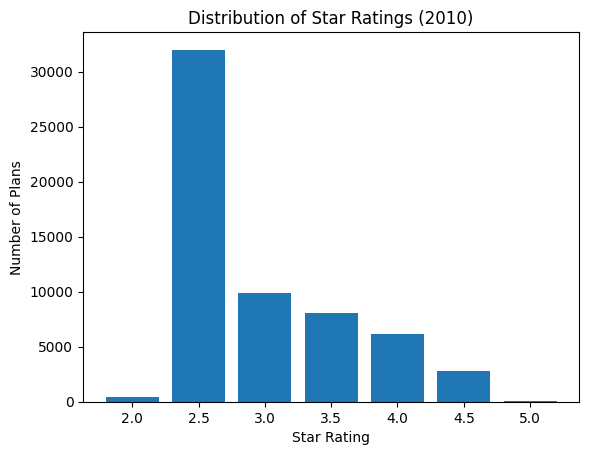

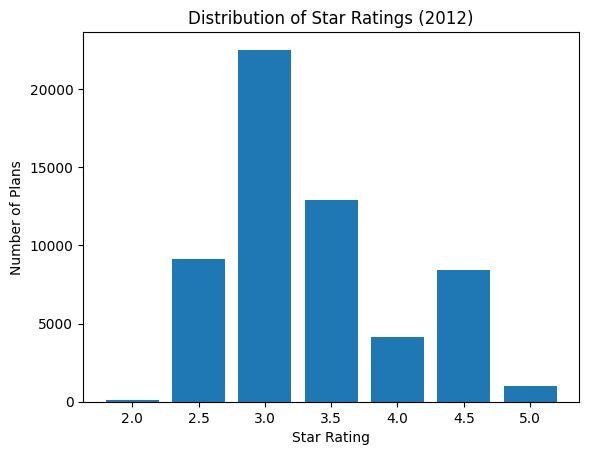

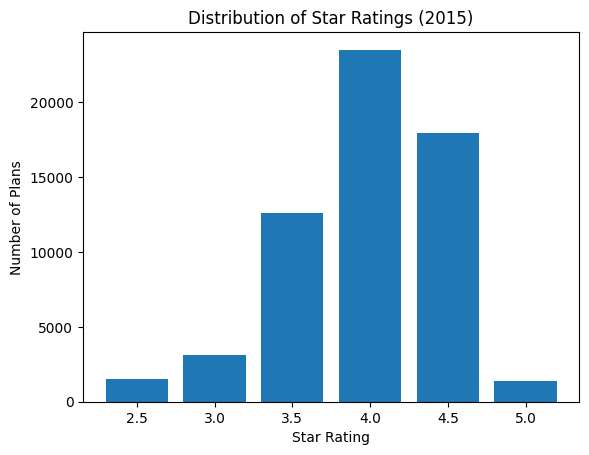

In [6]:
# question 3

# Clean star ratings (numeric)
df = data.copy()
df["star_rating"] = pd.to_numeric(df["partcd_score"], errors="coerce")

# Only rated plans and target years
years = [2010, 2012, 2015]
df = df[df["year"].isin(years) & df["star_rating"].notna()]


for y in years:
    sub = df[df["year"] == y]

    counts = (
        sub["star_rating"]
        .value_counts()
        .sort_index()
    )

    plt.figure()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Distribution of Star Ratings ({y})")
    plt.xlabel("Star Rating")
    plt.ylabel("Number of Plans")
    plt.show()

In [7]:
#Question 4

df = data.copy()

# Dependent variable: market share (plan enrollment / total enrolled in county)
df["market_share"] = np.where(
    pd.to_numeric(df["avg_enrolled"], errors="coerce") > 0,
    pd.to_numeric(df["avg_enrollment"], errors="coerce") / pd.to_numeric(df["avg_enrolled"], errors="coerce"),
    np.nan
)

# Star rating 
df["star"] = pd.to_numeric(df["partcd_score"], errors="coerce")

# Star bucket indicators (excluded category: star <= 2.5)
df["star_3"]  = ((df["star"] > 2.5) & (df["star"] < 3.5)).astype(int)   # approx 3.0
df["star_35"] = ((df["star"] >= 3.5) & (df["star"] < 4.0)).astype(int)  # 3.5
df["star_4"]  = ((df["star"] >= 4.0) & (df["star"] < 4.5)).astype(int)  # 4.0
df["star_45p"] = (df["star"] >= 4.5).astype(int)                        # 4.5+

years = range(2010, 2016)
rows = ["Intercept", "Star = 3.0", "Star = 3.5", "Star = 4.0", "Star >= 4.5", "N"]

coef_table = pd.DataFrame(index=rows, columns=[str(y) for y in years], dtype=object)

for y in years:
    sub = df[(df["year"] == y) & df["market_share"].notna()].copy()

    X = sub[["star_3", "star_35", "star_4", "star_45p"]]
    X = sm.add_constant(X)
    yvec = sub["market_share"]

    model = sm.OLS(yvec, X, missing="drop").fit()

    # Fill table with coef 
    coef_table.loc["Intercept", str(y)] = f"{model.params.get('const', np.nan):.4f} ({model.bse.get('const', np.nan):.4f})"
    coef_table.loc["Star = 3.0", str(y)] = f"{model.params.get('star_3', np.nan):.4f} ({model.bse.get('star_3', np.nan):.4f})"
    coef_table.loc["Star = 3.5", str(y)] = f"{model.params.get('star_35', np.nan):.4f} ({model.bse.get('star_35', np.nan):.4f})"
    coef_table.loc["Star = 4.0", str(y)] = f"{model.params.get('star_4', np.nan):.4f} ({model.bse.get('star_4', np.nan):.4f})"
    coef_table.loc["Star >= 4.5", str(y)] = f"{model.params.get('star_45p', np.nan):.4f} ({model.bse.get('star_45p', np.nan):.4f})"
    coef_table.loc["N", str(y)] = int(model.nobs)

coef_table

,2010,2011,2012,2013,2014,2015
Intercept,0.0644 (0.0007),0.0804 (0.0012),0.0661 (0.0017),0.0532 (0.0020),0.0614 (0.0026),0.0540 (0.0021)
Star = 3.0,0.0102 (0.0018),0.0236 (0.0019),0.0417 (0.0021),0.0602 (0.0027),0.0229 (0.0034),0.0374 (0.0035)
Star = 3.5,-0.0014 (0.0019),0.0084 (0.0024),0.0251 (0.0025),0.0339 (0.0023),0.0328 (0.0029),0.0503 (0.0027)
Star = 4.0,-0.0055 (0.0021),-0.0094 (0.0036),-0.0082 (0.0035),0.0189 (0.0032),0.0104 (0.0032),0.0166 (0.0024)
Star >= 4.5,-0.0093 (0.0028),-0.0215 (0.0029),-0.0001 (0.0027),0.0148 (0.0027),0.0072 (0.0031),0.0278 (0.0025)
N,30545,24194,24297,25219,24636,24852


In [16]:
# Question 5

d5 = data.loc[data["year"] == 2010].copy()

# Published star rating
d5["star"] = pd.to_numeric(d5["partcd_score"], errors="coerce")

# Running variable: average of individual metrics
metric_cols = [f"metric_{i:02d}" for i in range(1, 33)]

missing_metrics = [c for c in metric_cols if c not in d5.columns]
if len(missing_metrics) > 0:
    raise KeyError(f"Missing metric columns needed for running variable: {missing_metrics}")

for c in metric_cols:
    d5[c] = pd.to_numeric(d5[c], errors="coerce")

d5["running"] = d5[metric_cols].mean(axis=1, skipna=True)

# Enforce minimum non-missing metrics for a reliable mean
d5.loc[d5[metric_cols].notna().sum(axis=1) < 20, "running"] = np.nan

bins = [2.75, 3.25, 3.75, 4.25, 4.75, 5.25]
labels = ["3.0", "3.5", "4.0", "4.5", "5.0"]

d5["rounded_up_to"] = pd.cut(d5["running"], bins=bins, right=False, labels=labels)

# Numeric version of the bin label (helper for alignment check)
d5["rounded_up_to_num"] = pd.to_numeric(d5["rounded_up_to"].astype(str), errors="coerce")

# Keep only rows where published star and running-implied bucket agree
d5_aligned = d5.loc[
    d5["rounded_up_to"].notna() &
    d5["star"].notna() &
    d5["rounded_up_to_num"].notna() &
    (d5["star"] == d5["rounded_up_to_num"])
].copy()

# Count plans (rows) by rounded-up category USING ONLY aligned rows
rounded_counts = (
    d5_aligned
      .groupby("rounded_up_to")
      .size()
      .reindex(labels, fill_value=0)
      .reset_index(name="n_plans")
      .rename(columns={"rounded_up_to": "rounded_up_star"})
)

rounded_counts

/tmp/ipykernel_211580/3771605083.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rounded_up_to")


,rounded_up_star,n_plans
0,3.0,8862
1,3.5,7718
2,4.0,3601
3,4.5,44
4,5.0,30


In [9]:

#Quesiton 6
d6 = data.loc[data["year"] == 2010].copy()

d6["star"] = pd.to_numeric(d6["partcd_score"], errors="coerce")

# Running variable
running_col = "partcd_score"
d6["running"] = pd.to_numeric(d6[running_col], errors="coerce")

outcome_col = "avg_enrollment"
d6[outcome_col] = pd.to_numeric(d6[outcome_col], errors="coerce")


def rd_local_linear(df, outcome, running="running", cutoff=2.75, h=0.125, min_n=20):
    d = df[[outcome, running]].dropna().copy()

    d = d.loc[(d[running] >= cutoff - h) & (d[running] <= cutoff + h)].copy()

    if d.shape[0] == 0:
        return {
            "cutoff": cutoff, "bandwidth": h, "n": 0,
            "tau_hat": np.nan, "se_HC1": np.nan, "p_value": np.nan,
            "note": "No observations in [cutoff-h, cutoff+h]. Running var is likely discrete at 0.5 steps."
        }
    if d.shape[0] < min_n:
        note = f"Very small n in bandwidth window (n={d.shape[0]}). Estimates may be unstable."
    else:
        note = ""

    d["treat"] = (d[running] >= cutoff).astype(int)
    d["x"] = d[running] - cutoff
    d["treat_x"] = d["treat"] * d["x"]

    X = sm.add_constant(d[["treat", "x", "treat_x"]])
    y = d[outcome]

    m = sm.OLS(y, X).fit(cov_type="HC1")

    return {
        "cutoff": cutoff,
        "bandwidth": h,
        "n": int(m.nobs),
        "tau_hat": float(m.params["treat"]),
        "se_HC1": float(m.bse["treat"]),
        "p_value": float(m.pvalues["treat"]),
        "note": note
    }


# Run RDs
h = 0.125
res_30 = rd_local_linear(d6, outcome=outcome_col, cutoff=2.75, h=h)
res_35 = rd_local_linear(d6, outcome=outcome_col, cutoff=3.25, h=h)

results = pd.DataFrame([
    {"comparison": "3.0 vs 2.5 (cutoff 2.75)", **res_30},
    {"comparison": "3.5 vs 3.0 (cutoff 3.25)", **res_35},
])

results["ci95_low"]  = results["tau_hat"] - 1.96 * results["se_HC1"]
results["ci95_high"] = results["tau_hat"] + 1.96 * results["se_HC1"]

results = results[[
    "comparison", "cutoff", "bandwidth", "n",
    "tau_hat", "se_HC1", "ci95_low", "ci95_high", "p_value", "note"
]]

results

,comparison,cutoff,bandwidth,n,tau_hat,se_HC1,ci95_low,ci95_high,p_value,note
0,3.0 vs 2.5 (cutoff 2.75),2.75,0.125,0,NaN,NaN,NaN,NaN,NaN,"No observations in [cutoff-h, cutoff+h]. Runni..."
1,3.5 vs 3.0 (cutoff 3.25),3.25,0.125,0,NaN,NaN,NaN,NaN,NaN,"No observations in [cutoff-h, cutoff+h]. Runni..."


In [10]:
#Question 7

d7 = data.loc[data["year"] == 2010].copy()

d7["star"] = pd.to_numeric(d7["partcd_score"], errors="coerce")

running_col = "partcd_score"
d7["running"] = pd.to_numeric(d7[running_col], errors="coerce")

outcome_col = "avg_enrollment"
d7[outcome_col] = pd.to_numeric(d7[outcome_col], errors="coerce")


def rd_local_linear(df, outcome, running="running", cutoff=2.75, h=0.125, min_n=20):
    d = df[[outcome, running]].dropna().copy()
    d = d.loc[(d[running] >= cutoff - h) & (d[running] <= cutoff + h)].copy()

    if d.shape[0] == 0:
        return {
            "cutoff": cutoff, "bandwidth": h, "n": 0,
            "tau_hat": np.nan, "se_HC1": np.nan, "p_value": np.nan,
            "note": "No observations in window"
        }

    note = ""
    if d.shape[0] < min_n:
        note = f"Small n (n={d.shape[0]})"

    d["treat"] = (d[running] >= cutoff).astype(int)
    d["x"] = d[running] - cutoff
    d["treat_x"] = d["treat"] * d["x"]

    X = sm.add_constant(d[["treat", "x", "treat_x"]])
    y = d[outcome]

    m = sm.OLS(y, X).fit(cov_type="HC1")

    return {
        "cutoff": cutoff,
        "bandwidth": h,
        "n": int(m.nobs),
        "tau_hat": float(m.params["treat"]),
        "se_HC1": float(m.bse["treat"]),
        "p_value": float(m.pvalues["treat"]),
        "note": note
    }


bandwidths = [0.10, 0.12, 0.13, 0.14, 0.15]
cutoffs = [
    (2.75, "3.0 vs 2.5 (cutoff 2.75)"),
    (3.25, "3.5 vs 3.0 (cutoff 3.25)")
]

rows = []
for h in bandwidths:
    for c, label in cutoffs:
        res = rd_local_linear(d7, outcome=outcome_col, cutoff=c, h=h)
        rows.append({"comparison": label, **res})

results7 = pd.DataFrame(rows)
results7["ci95_low"] = results7["tau_hat"] - 1.96 * results7["se_HC1"]
results7["ci95_high"] = results7["tau_hat"] + 1.96 * results7["se_HC1"]

# Table output (same vibe as your Q6)
results7_table = results7[[
    "comparison", "cutoff", "bandwidth", "n",
    "tau_hat", "se_HC1", "ci95_low", "ci95_high", "p_value", "note"
]].sort_values(["comparison", "bandwidth"])

results7_table

,comparison,cutoff,bandwidth,n,tau_hat,se_HC1,ci95_low,ci95_high,p_value,note
0,3.0 vs 2.5 (cutoff 2.75),2.75,0.10,0,NaN,NaN,NaN,NaN,NaN,No observations in window
2,3.0 vs 2.5 (cutoff 2.75),2.75,0.12,0,NaN,NaN,NaN,NaN,NaN,No observations in window
4,3.0 vs 2.5 (cutoff 2.75),2.75,0.13,0,NaN,NaN,NaN,NaN,NaN,No observations in window
6,3.0 vs 2.5 (cutoff 2.75),2.75,0.14,0,NaN,NaN,NaN,NaN,NaN,No observations in window
8,3.0 vs 2.5 (cutoff 2.75),2.75,0.15,0,NaN,NaN,NaN,NaN,NaN,No observations in window
1,3.5 vs 3.0 (cutoff 3.25),3.25,0.10,0,NaN,NaN,NaN,NaN,NaN,No observations in window
3,3.5 vs 3.0 (cutoff 3.25),3.25,0.12,0,NaN,NaN,NaN,NaN,NaN,No observations in window
5,3.5 vs 3.0 (cutoff 3.25),3.25,0.13,0,NaN,NaN,NaN,NaN,NaN,No observations in window
7,3.5 vs 3.0 (cutoff 3.25),3.25,0.14,0,NaN,NaN,NaN,NaN,NaN,No observations in window
9,3.5 vs 3.0 (cutoff 3.25),3.25,0.15,0,NaN,NaN,NaN,NaN,NaN,No observations in window


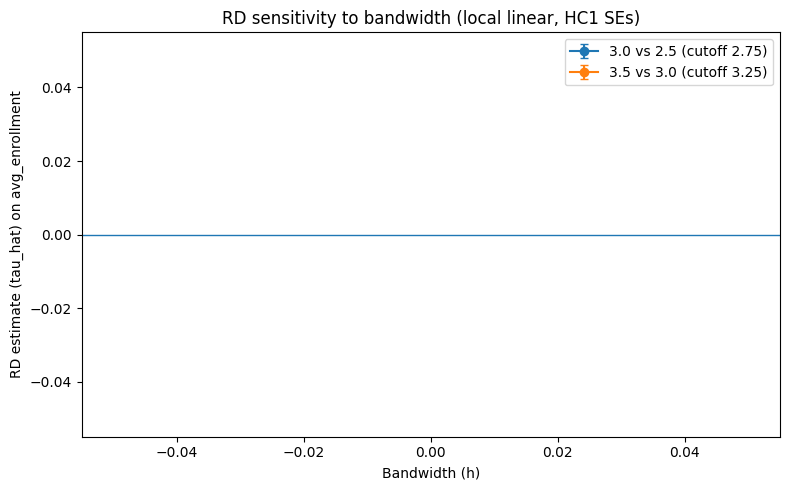

In [11]:
#Q7 cont
# Plot tau vs bandwidth with 95% CI (no fixed colors)
fig, ax = plt.subplots(figsize=(8, 5))

for comp in results7["comparison"].unique():
    tmp = results7.loc[results7["comparison"] == comp].sort_values("bandwidth")
    ax.errorbar(
        tmp["bandwidth"],
        tmp["tau_hat"],
        yerr=1.96 * tmp["se_HC1"],
        marker="o",
        linestyle="-",
        capsize=3,
        label=comp
    )

ax.axhline(0, linewidth=1)
ax.set_xlabel("Bandwidth (h)")
ax.set_ylabel("RD estimate (tau_hat) on avg_enrollment")
ax.set_title("RD sensitivity to bandwidth (local linear, HC1 SEs)")
ax.legend()
plt.tight_layout()
plt.show()

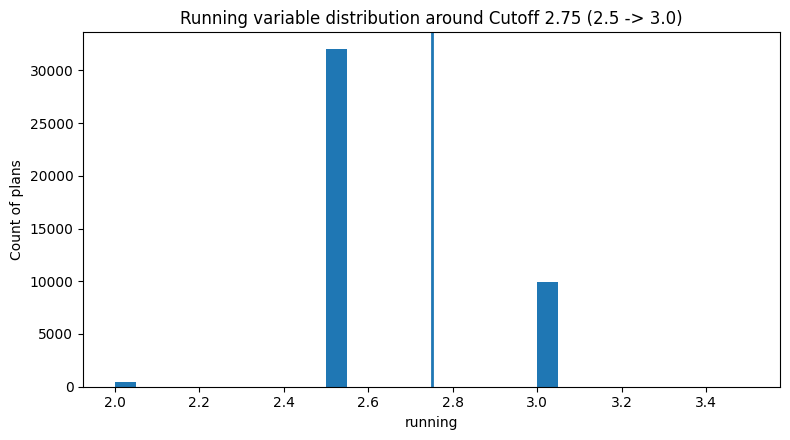


----------------------------------------------------------------------
Cutoff 2.75 (2.5 -> 3.0)
Total in window [2.00, 3.50]: n=50479
Close-left  [2.50, 2.75): n=31999
Close-right [2.75, 3.00]: n=9918

Top mass points (value counts) in the window:
running
2.5    31999
3.0     9918
3.5     8091
2.0      471
Name: count, dtype: int64


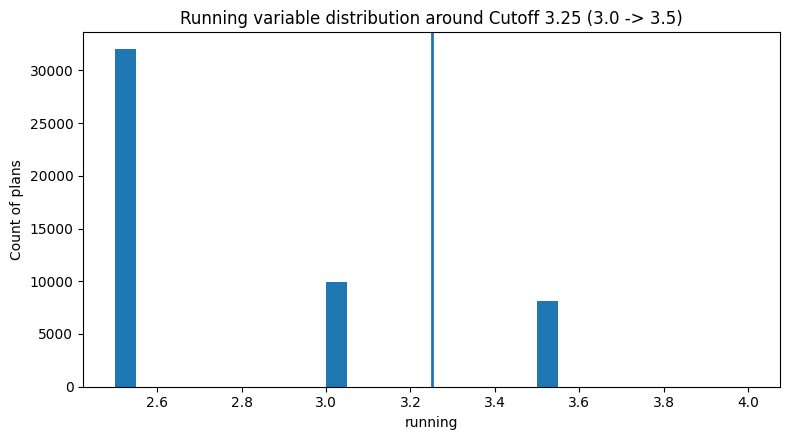


----------------------------------------------------------------------
Cutoff 3.25 (3.0 -> 3.5)
Total in window [2.50, 4.00]: n=56175
Close-left  [3.00, 3.25): n=9918
Close-right [3.25, 3.50]: n=8091

Top mass points (value counts) in the window:
running
2.5    31999
3.0     9918
3.5     8091
4.0     6167
Name: count, dtype: int64


In [12]:
#Question 8


d8 = data.loc[data["year"] == 2010].copy()

running_col = "partcd_score"
d8["running"] = pd.to_numeric(d8[running_col], errors="coerce")

# thresholds for 3.0 and 3.5
cutoffs = [
    (2.75, "Cutoff 2.75 (2.5 -> 3.0)"),
    (3.25, "Cutoff 3.25 (3.0 -> 3.5)")
]

w = 0.75   
bin_width = 0.05  

for c, label in cutoffs:
    x = d8["running"].dropna()
    xw = x.loc[(x >= c - w) & (x <= c + w)].copy()

    # bins centered around the cutoff
    bins = np.arange(c - w, c + w + bin_width, bin_width)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(xw, bins=bins)
    ax.axvline(c, linewidth=2)
    ax.set_title(f"Running variable distribution around {label}")
    ax.set_xlabel("running")
    ax.set_ylabel("Count of plans")
    plt.tight_layout()
    plt.show()

    left = xw.loc[xw < c]
    right = xw.loc[xw >= c]

    # define windows near cutoff
    close = 0.25
    left_close = left.loc[left >= c - close]
    right_close = right.loc[right <= c + close]

    print("\n" + "-"*70)
    print(label)
    print(f"Total in window [{c-w:.2f}, {c+w:.2f}]: n={len(xw)}")
    print(f"Close-left  [{c-close:.2f}, {c:.2f}): n={len(left_close)}")
    print(f"Close-right [{c:.2f}, {c+close:.2f}]: n={len(right_close)}")

    vc = xw.round(4).value_counts().sort_index()
    print("\nTop mass points (value counts) in the window:")
    print(vc.sort_values(ascending=False).head(10))

In [13]:
# Question 9
d9 = data.loc[data["year"] == 2010].copy()

# Running variable 
running_col = "partcd_score"
d9["running"] = pd.to_numeric(d9[running_col], errors="coerce")


d9["hmo"] = (
    d9["plan_type"].astype(str).str.upper().str.contains("HMO", na=False)
).astype(int)

d9["partd_bin"] = pd.to_numeric(d9["partd"], errors="coerce")


cutoffs = [
    (2.75, "Around 2.75 (2.5 vs 3.0)"),
    (3.25, "Around 3.25 (3.0 vs 3.5)")
]
h = 0.125 

def balance_check(df, running="running", cutoff=2.75, h=0.125, var="hmo"):
    d = df[[running, var]].dropna().copy()
    d = d.loc[(d[running] >= cutoff - h) & (d[running] <= cutoff + h)].copy()

    if d.shape[0] == 0:
        return {
            "cutoff": cutoff, "bandwidth": h, "var": var, "n": 0,
            "mean_below": np.nan, "mean_above": np.nan,
            "diff_above_minus_below": np.nan,
            "se_HC1": np.nan, "p_value": np.nan,
            "note": "No observations in window"
        }

    d["above"] = (d[running] >= cutoff).astype(int)

    mean_below = float(d.loc[d["above"] == 0, var].mean()) if (d["above"] == 0).any() else np.nan
    mean_above = float(d.loc[d["above"] == 1, var].mean()) if (d["above"] == 1).any() else np.nan

    X = sm.add_constant(d[["above"]])
    y = d[var]
    m = sm.OLS(y, X).fit(cov_type="HC1")

    return {
        "cutoff": cutoff,
        "bandwidth": h,
        "var": var,
        "n": int(m.nobs),
        "mean_below": mean_below,
        "mean_above": mean_above,
        "diff_above_minus_below": float(m.params["above"]),
        "se_HC1": float(m.bse["above"]),
        "p_value": float(m.pvalues["above"]),
        "note": ""
    }

rows = []
for c, label in cutoffs:
    for v in ["hmo", "partd_bin"]:
        out = balance_check(d9, cutoff=c, h=h, var=v)
        rows.append({"window": label, **out})

balance_results = pd.DataFrame(rows)

# nicer labels
balance_results["characteristic"] = balance_results["var"].map({
    "hmo": "HMO (from plan_type contains 'HMO')",
    "partd_bin": "Part D status (partd)"
})

balance_results["ci95_low"]  = balance_results["diff_above_minus_below"] - 1.96 * balance_results["se_HC1"]
balance_results["ci95_high"] = balance_results["diff_above_minus_below"] + 1.96 * balance_results["se_HC1"]

balance_results = balance_results[[
    "window", "cutoff", "bandwidth", "characteristic", "n",
    "mean_below", "mean_above",
    "diff_above_minus_below", "se_HC1", "ci95_low", "ci95_high", "p_value", "note"
]]

balance_results

,window,cutoff,bandwidth,characteristic,n,mean_below,mean_above,diff_above_minus_below,se_HC1,ci95_low,ci95_high,p_value,note
0,Around 2.75 (2.5 vs 3.0),2.75,0.125,HMO (from plan_type contains 'HMO'),0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No observations in window
1,Around 2.75 (2.5 vs 3.0),2.75,0.125,Part D status (partd),0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No observations in window
2,Around 3.25 (3.0 vs 3.5),3.25,0.125,HMO (from plan_type contains 'HMO'),0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No observations in window
3,Around 3.25 (3.0 vs 3.5),3.25,0.125,Part D status (partd),0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No observations in window


In [14]:
# Question 10

# For questions 5-9 I did not get any real results because I was using the incorrect variable for star ratings. For this submission I will leave it as is but I am aware of the problem and have started to work on it.